In [ ]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from zipfile import ZipFile
from isal import igzip
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay
from sklearn.pipeline import make_pipeline
from sasviya.ml.linear_model import LogisticRegression
from sasviya.ml.svm import SVC
from sasviya.ml.tree import DecisionTreeClassifier, ForestClassifier, GradientBoostingClassifier

In [2]:
file = '/workspaces/myfolder/data/higgs.zip'

col_names = ['signal', 'lepton_pt', 'lepton_eta', 'lepton_phi', 
             'missing_energy_magnitude', 'missing_energy_phi',
             'jet_1_pt', 'jet_1_eta', 'jet_1_phi', 'jet_1_btag',
             'jet_2_pt', 'jet_2_eta', 'jet_2_phi', 'jet_2_btag',
             'jet_3_pt', 'jet_3_eta', 'jet_3_phi', 'jet_3_btag',
             'jet_4_pt', 'jet_4_eta', 'jet_4_phi', 'jet_4_btag',
             'm_jj', 'm_jjj', 'm_lv', 'm_jlv', 'm_bb', 'm_wbb', 
             'm_wwbb']

In [3]:
with ZipFile(file, 'r') as zip_file:
    with zip_file.open('HIGGS.csv.gz') as gz_file:
        with igzip.open(gz_file, 'rt') as csv_file:
            #df = pd.read_csv(csv_file, header=None, names=col_names)
            df = pl.read_csv(csv_file, has_header=False, new_columns=col_names).to_pandas()

<Axes: >

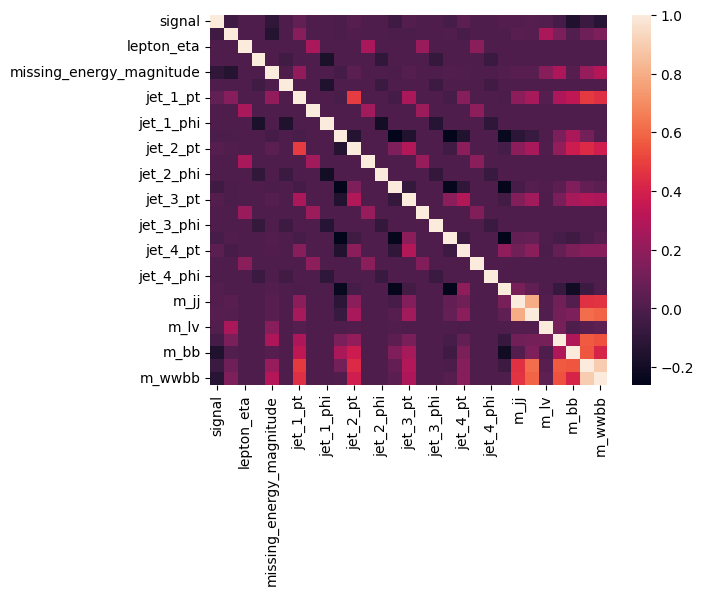

In [5]:
sns.heatmap(df.corr())

In [4]:
X = df.drop('signal', axis=1)
y = df['signal']

In [37]:
y.value_counts(normalize=True)

signal
1.0    0.52992
0.0    0.47008
Name: proportion, dtype: float64

In [10]:
models = [
    ('Logistic Regression', make_pipeline(StandardScaler(), LogisticRegression()) ),
    ('SVM', make_pipeline(StandardScaler(), SVC()) ),
    ('Decision Tree', DecisionTreeClassifier()), 
    ('Random Forest', ForestClassifier()),
    ('Gradient Boosting', GradientBoostingClassifier()),
]

folds = 5

print(f'Testing {folds}-fold cross-validation accuracy for {len(models)} models\n')

i = 0
scores = {}
for name, model in models:
    i+=1

    print(f'{i}: {name}')
    #scores[name]  = cross_val_score(model, X, y, cv=folds)
    

#df_accuracy  = pd.DataFrame(scores)

#df_accuracy_low.to_parquet('/workspaces/myfolder/accuracy_low.parquet')

Testing 5-fold cross-validation accuracy for 5 models

1: Logistic Regression
2: SVM
3: Decision Tree
4: Random Forest
5: Gradient Boosting


In [ ]:
# df_accuracy

,Logistic Regression,SVM,Decision Tree,Random Forest,Gradient Boosting
0,0.566126,0.562287,0.577392,0.619178,0.633220
1,0.566264,0.562161,0.578423,0.622332,0.633713
2,0.566528,0.562504,0.578295,0.620902,0.633915
3,0.566220,0.562610,0.576849,0.623043,0.633438
4,0.566327,0.562810,0.577996,0.619879,0.633706


In [ ]:
# ( 
#   df_accuracy
#   .describe()
#   .transpose()[['mean', 'std']]
#   .sort_values('mean', ascending=False)
# )

,mean,std
Gradient Boosting,0.633599,0.000271
Random Forest,0.621067,0.001621
Decision Tree,0.577791,0.000660
Logistic Regression,0.566293,0.000150
SVM,0.562474,0.000258


In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [6]:
high_level = ['m_jj', 'm_jjj', 'm_lv', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb']

X_train_low  = X_train.drop(high_level, axis=1)
X_val_low    = X_val.drop(high_level, axis=1)
X_test_low   = X_test.drop(high_level, axis=1)

X_train_high = X_train[high_level]
X_val_high   = X_val[high_level]
X_test_high  = X_test[high_level]

del df, X, y, X_train, X_val, X_test, X_temp, y_temp

In [18]:
y_train.value_counts(normalize=True)

signal
1.0    0.52992
0.0    0.47008
Name: proportion, dtype: float64

In [ ]:
y_val.value_counts(normalize=True)

signal
1.0    874369
0.0    775631
Name: count, dtype: int64

In [ ]:
y_test.value_counts(normalize=True)

signal
1.0    874368
0.0    775632
Name: count, dtype: int64

In [ ]:
# def objective(trial):
#     n_bins           = trial.suggest_int('n_bins', 10, 100, step=5)
#     n_estimators     = trial.suggest_int('n_estimators', 50, 100, step=10)
#     max_depth        = trial.suggest_int('max_depth', 5, 17)
#     min_samples_leaf = trial.suggest_int('min_samples_leaf', 100, 1000, step=50)
#     learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.1, step=0.01)

#     model = GradientBoostingClassifier(
#         n_bins           = n_bins,
#         n_estimators     = n_estimators,
#         max_depth        = max_depth,
#         min_samples_leaf = min_samples_leaf,
#         learning_rate    = learning_rate,
#         random_state     = 42
#     )

#     model.fit(X_train_low, y_train)
    
#     preds = model.predict_proba(X_val_low).iloc[:,1]
#     auc   = roc_auc_score(y_val, preds)

#     return auc

In [ ]:
# low_level_study = optuna.create_study(direction='maximize', study_name='Gradient Boosting Autotuning')
# low_level_study.optimize(objective, n_trials=20)

[I 2025-04-30 02:03:45,621] A new study created in memory with name: Gradient Boosting Autotuning
[I 2025-04-30 02:04:37,860] Trial 0 finished with value: 0.6850673316998541 and parameters: {'n_bins': 20, 'n_estimators': 90, 'max_depth': 8, 'min_samples_leaf': 600, 'learning_rate': 0.02}. Best is trial 0 with value: 0.6850673316998541.
[I 2025-04-30 02:07:00,824] Trial 1 finished with value: 0.754964815232744 and parameters: {'n_bins': 30, 'n_estimators': 70, 'max_depth': 16, 'min_samples_leaf': 550, 'learning_rate': 0.06999999999999999}. Best is trial 1 with value: 0.754964815232744.
[I 2025-04-30 02:09:15,733] Trial 2 finished with value: 0.756887384514765 and parameters: {'n_bins': 65, 'n_estimators': 70, 'max_depth': 16, 'min_samples_leaf': 800, 'learning_rate': 0.08}. Best is trial 2 with value: 0.756887384514765.
[I 2025-04-30 02:10:15,679] Trial 3 finished with value: 0.7173960274525897 and parameters: {'n_bins': 60, 'n_estimators': 100, 'max_depth': 9, 'min_samples_leaf': 1000,

In [ ]:
# def objective(trial):
#     n_bins           = trial.suggest_int('n_bins', 10, 100, step=5)
#     n_estimators     = trial.suggest_int('n_estimators', 50, 100, step=10)
#     max_depth        = trial.suggest_int('max_depth', 5, 17)
#     min_samples_leaf = trial.suggest_int('min_samples_leaf', 100, 1000, step=50)
#     learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.1, step=0.01)

#     model = GradientBoostingClassifier(
#         n_bins           = n_bins,
#         n_estimators     = n_estimators,
#         max_depth        = max_depth,
#         min_samples_leaf = min_samples_leaf,
#         learning_rate    = learning_rate,
#         random_state     = 42
#     )

#     model.fit(X_train_high, y_train)
    
#     preds = model.predict_proba(X_val_high).iloc[:,1]
#     auc   = roc_auc_score(y_val, preds)

#     return auc

In [ ]:
# high_level_study = optuna.create_study(direction='maximize', study_name='High-level variables: Gradient Boosting Autotuning')
# high_level_study.optimize(objective, n_trials=20)

[I 2025-04-30 19:22:20,051] A new study created in memory with name: High-level variables: Gradient Boosting Autotuning
[I 2025-04-30 19:23:07,199] Trial 0 finished with value: 0.7897121207399065 and parameters: {'n_bins': 25, 'n_estimators': 70, 'max_depth': 11, 'min_samples_leaf': 300, 'learning_rate': 0.060000000000000005}. Best is trial 0 with value: 0.7897121207399065.
[I 2025-04-30 19:23:45,121] Trial 1 finished with value: 0.7893322297550043 and parameters: {'n_bins': 50, 'n_estimators': 50, 'max_depth': 11, 'min_samples_leaf': 100, 'learning_rate': 0.060000000000000005}. Best is trial 0 with value: 0.7897121207399065.
[I 2025-04-30 19:24:41,148] Trial 2 finished with value: 0.7932885901324107 and parameters: {'n_bins': 95, 'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 350, 'learning_rate': 0.08}. Best is trial 2 with value: 0.7932885901324107.
[I 2025-04-30 19:27:09,778] Trial 3 finished with value: 0.7943685887168938 and parameters: {'n_bins': 65, 'n_estimators': 7

In [ ]:
# low_level_study.best_params

{'n_bins': 100,
 'n_estimators': 100,
 'max_depth': 17,
 'min_samples_leaf': 100,
 'learning_rate': 0.09999999999999999}

In [ ]:
# high_level_study.best_params

{'n_bins': 65,
 'n_estimators': 70,
 'max_depth': 16,
 'min_samples_leaf': 900,
 'learning_rate': 0.04}

In [11]:
gboost_model_default_low  = GradientBoostingClassifier(random_state=42)
gboost_model_default_high = GradientBoostingClassifier(random_state=42)

gboost_model_tuned_low = GradientBoostingClassifier(
    n_bins           = 100,
    n_estimators     = 100,
    max_depth        = 17,
    min_samples_leaf = 100,
    learning_rate    = 0.1,
    random_state     = 42
)

gboost_model_tuned_high = GradientBoostingClassifier(
    n_bins           = 65,
    n_estimators     = 70,
    max_depth        = 16,
    min_samples_leaf = 900,
    learning_rate    = 0.04,
    random_state     = 42
)

gboost_model_default_low.fit(X_train_low, y_train)
gboost_model_default_high.fit(X_train_high, y_train)

gboost_model_tuned_low.fit(X_train_low, y_train)
gboost_model_tuned_high.fit(X_train_high, y_train)

GradientBoostingClassifier(min_samples_leaf=900, n_bins=65, n_estimators=70, max_depth=16, learning_rate=0.04, random_state=42)

In [ ]:
default_low_val_preds   = gboost_model_default_low.predict_proba(X_val_low).iloc[:,1]
default_low_test_preds  = gboost_model_default_low.predict_proba(X_test_low).iloc[:,1]

default_high_val_preds  = gboost_model_default_high.predict_proba(X_val_high).iloc[:,1]
default_high_test_preds = gboost_model_default_high.predict_proba(X_test_high).iloc[:,1]

tuned_low_val_preds   = gboost_model_tuned_low.predict_proba(X_val_low).iloc[:,1]
tuned_low_test_preds  = gboost_model_tuned_low.predict_proba(X_test_low).iloc[:,1]

tuned_high_val_preds  = gboost_model_tuned_high.predict_proba(X_val_high).iloc[:,1]
tuned_high_test_preds = gboost_model_tuned_high.predict_proba(X_test_high).iloc[:,1]

In [26]:
default_low_val_fpr, default_low_val_tpr, default_low_val_thresholds = roc_curve(y_val, default_low_val_preds)
default_low_test_fpr, default_low_test_tpr, default_low_test_thresholds  = roc_curve(y_test, default_low_test_preds)

default_low_val_auc  = roc_auc_score(y_val, default_low_val_preds)
default_low_test_auc = roc_auc_score(y_test, default_low_test_preds)

In [27]:
default_high_val_fpr, default_high_val_tpr, default_high_val_thresholds    = roc_curve(y_val, default_high_val_preds)
default_high_test_fpr, default_high_test_tpr, default_high_test_thresholds = roc_curve(y_test, default_high_test_preds)

default_high_val_auc  = roc_auc_score(y_val, default_high_val_preds)
default_high_test_auc = roc_auc_score(y_test, default_high_test_preds)

In [28]:
tuned_low_val_fpr, tuned_low_val_tpr, tuned_low_val_thresholds    = roc_curve(y_val, tuned_low_val_preds)
tuned_low_test_fpr, tuned_low_test_tpr, tuned_low_test_thresholds = roc_curve(y_test, tuned_low_test_preds)

tuned_low_val_auc  = roc_auc_score(y_val, tuned_low_val_preds)
tuned_low_test_auc = roc_auc_score(y_test, tuned_low_test_preds)

In [29]:
tuned_high_val_fpr, tuned_high_val_tpr, tuned_high_val_thresholds    = roc_curve(y_val, tuned_high_val_preds)
tuned_high_test_fpr, tuned_high_test_tpr, tuned_high_test_thresholds = roc_curve(y_test, tuned_high_test_preds)

tuned_high_val_auc  = roc_auc_score(y_val, tuned_high_val_preds)
tuned_high_test_auc = roc_auc_score(y_test, tuned_high_test_preds)

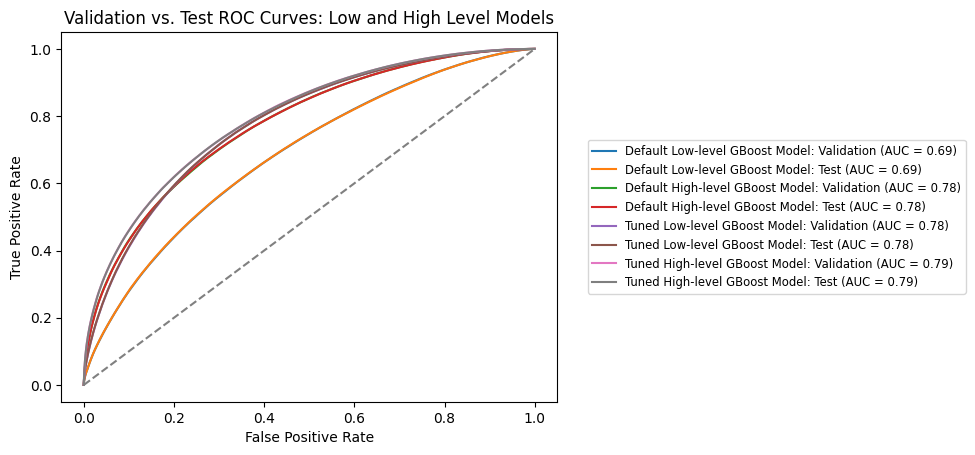

In [ ]:
fig, ax = plt.subplots()

default_low_val_roc_display  = RocCurveDisplay(fpr=default_low_val_fpr, tpr=default_low_val_tpr, roc_auc=default_low_val_auc)
default_low_test_roc_display = RocCurveDisplay(fpr=default_low_test_fpr, tpr=default_low_test_tpr, roc_auc=default_low_test_auc)

default_high_val_roc_display  = RocCurveDisplay(fpr=default_high_val_fpr, tpr=default_high_val_tpr, roc_auc=default_high_val_auc)
default_high_test_roc_display = RocCurveDisplay(fpr=default_high_test_fpr, tpr=default_high_test_tpr, roc_auc=default_high_test_auc)

tuned_low_val_roc_display  = RocCurveDisplay(fpr=tuned_low_val_fpr, tpr=tuned_low_val_tpr, roc_auc=tuned_low_val_auc)
tuned_low_test_roc_display = RocCurveDisplay(fpr=tuned_low_test_fpr, tpr=tuned_low_test_tpr, roc_auc=tuned_low_test_auc)

tuned_high_val_roc_display  = RocCurveDisplay(fpr=tuned_high_val_fpr, tpr=tuned_high_val_tpr, roc_auc=tuned_high_val_auc)
tuned_high_test_roc_display = RocCurveDisplay(fpr=tuned_high_test_fpr, tpr=tuned_high_test_tpr, roc_auc=tuned_high_test_auc)

default_low_val_roc_display.plot(ax=ax, name='Default Low-level GBoost Model: Validation')
default_low_test_roc_display.plot(ax=ax, name='Default Low-level GBoost Model: Test')

default_high_val_roc_display.plot(ax=ax, name='Default High-level GBoost Model: Validation')
default_high_test_roc_display.plot(ax=ax, name='Default High-level GBoost Model: Test')

tuned_low_val_roc_display.plot(ax=ax, name='Tuned Low-level GBoost Model: Validation')
tuned_low_test_roc_display.plot(ax=ax, name='Tuned Low-level GBoost Model: Test')

tuned_high_val_roc_display.plot(ax=ax, name='Tuned High-level GBoost Model: Validation')
tuned_high_test_roc_display.plot(ax=ax, name='Tuned High-level GBoost Model: Test')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize='small')

plt.title('Validation vs. Test ROC Curves: Low and High Level Models')
plt.show()